# 02 — EDA Forecasting
## Temporal Patterns in Daily Item Demand

**Purpose.** Before building any model, we need to understand *what patterns
exist* in the demand data. This notebook decomposes the time series into its
components: trend, weekly seasonality, monthly seasonality, holiday effects,
Ramadan impact, and item-level seasonality. Every pattern we find here becomes
a feature or a modeling decision in the next notebooks.

**Input:** `daily_item_demand.csv` (built in notebook 01)

**What this notebook covers:**
1. Overall demand trend
2. Weekly seasonality (aggregate + per-section)
3. Monthly seasonality
4. Holiday and Ramadan effects
5. Item-level seasonality (summer vs winter items)
6. Autocorrelation analysis — how far back does demand predict the future?
7. Decomposition (trend + seasonal + residual)
8. Key takeaways for feature engineering

---


## 1. Setup and data loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH ===
DATASETS_DIR = '../../datasets'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\Forecasting


In [2]:
# Load the daily demand table from notebook 01
demand = pd.read_csv(os.path.join(DATASETS_DIR, 'daily_item_demand.csv'))
demand['order_date'] = pd.to_datetime(demand['order_date'])

print(f"Loaded: {len(demand):,} rows")
print(f"Date range: {demand['order_date'].min().date()} → {demand['order_date'].max().date()}")
print(f"Items: {demand['item_name'].nunique()}")
print(f"Sections: {demand['section'].nunique()}")

# Pre-compute aggregate daily totals (used throughout)
daily_total = demand.groupby('order_date')['quantity'].sum().sort_index()
print(f"\nDaily total items: mean={daily_total.mean():.1f}, std={daily_total.std():.1f}")

Loaded: 133,712 rows
Date range: 2023-01-01 → 2025-12-31
Items: 122
Sections: 7

Daily total items: mean=160.5, std=42.8


## 2. Overall demand trend

Is the business growing, flat, or declining? The trend component tells us
whether the model needs a linear (or non-linear) growth term.

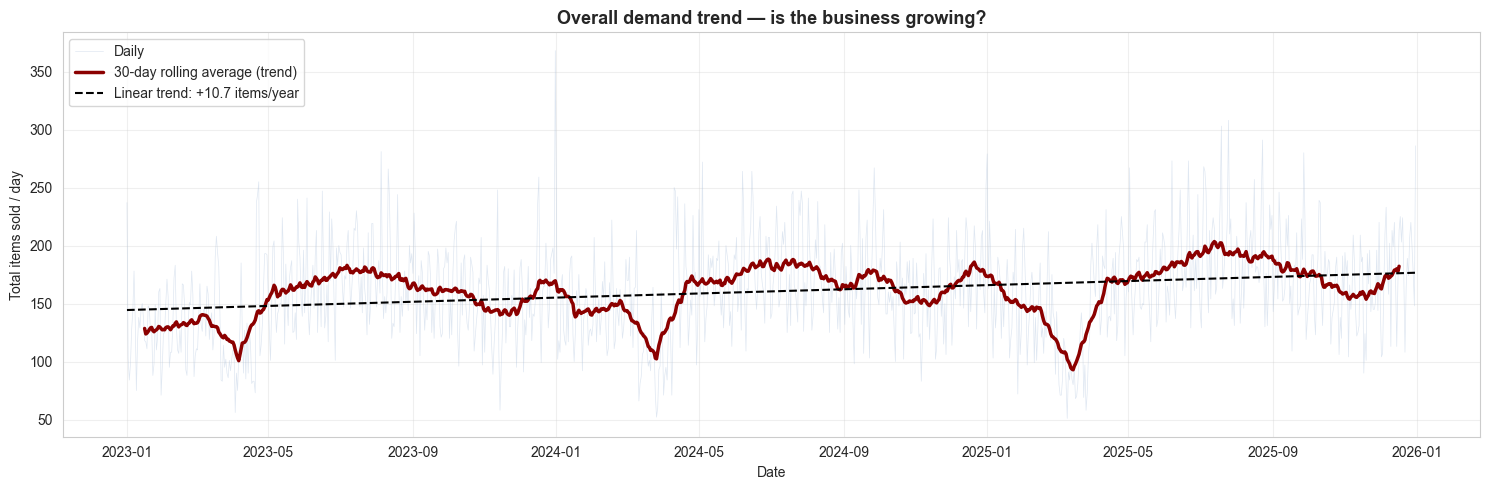

Linear trend slope: +0.03 items/day per day
Annualized: +11 items/year
Total growth over 36 months: +22.3%


In [3]:
fig, ax = plt.subplots(figsize=(15, 5))

# 30-day rolling average to show trend
rolling_30 = daily_total.rolling(30, center=True).mean()

ax.plot(daily_total.index, daily_total.values, color='lightsteelblue',
        linewidth=0.5, alpha=0.4, label='Daily')
ax.plot(rolling_30.index, rolling_30.values, color='darkred', linewidth=2.5,
        label='30-day rolling average (trend)')

# Fit a simple linear trend line
x_numeric = (daily_total.index - daily_total.index[0]).days
z = np.polyfit(x_numeric, daily_total.values, 1)
trend_line = np.polyval(z, x_numeric)
ax.plot(daily_total.index, trend_line, '--', color='black', linewidth=1.5,
        label=f'Linear trend: +{z[0]*365:.1f} items/year')

ax.set_title('Overall demand trend — is the business growing?')
ax.set_ylabel('Total items sold / day')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

growth_pct = (trend_line[-1] / trend_line[0] - 1) * 100
print(f"Linear trend slope: +{z[0]:.2f} items/day per day")
print(f"Annualized: +{z[0]*365:.0f} items/year")
print(f"Total growth over 36 months: +{growth_pct:.1f}%")

## 3. Weekly seasonality

The most exploitable pattern in restaurant data. Which days are busiest?
Does the pattern differ by section?

### 3.1 Aggregate weekly pattern

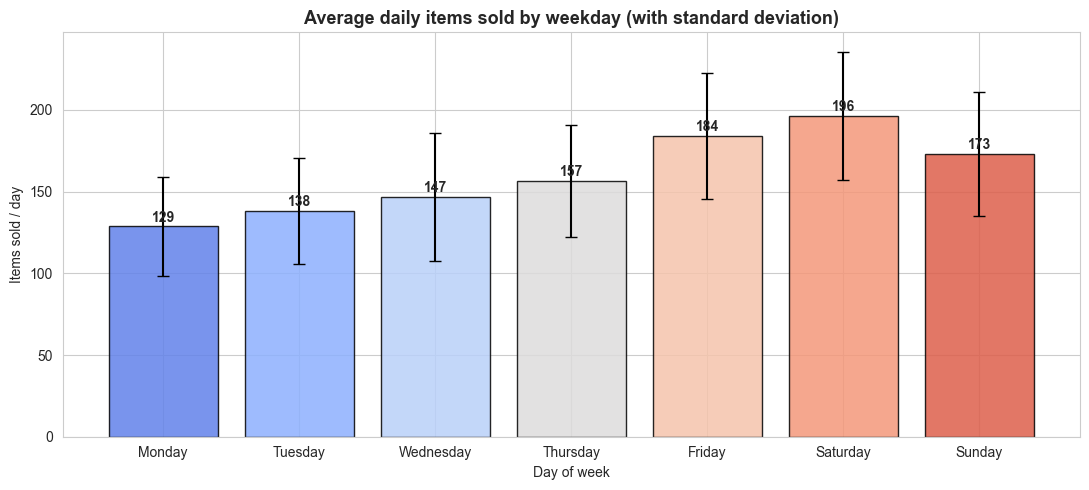

Saturday / Monday ratio: 1.53x


In [4]:
# Add temporal features
demand['weekday'] = demand['order_date'].dt.weekday
demand['weekday_name'] = demand['order_date'].dt.day_name()
demand['month'] = demand['order_date'].dt.month
demand['year'] = demand['order_date'].dt.year

# Aggregate: total items sold per weekday, averaged across all weeks
wd_daily = demand.groupby(['order_date', 'weekday'])['quantity'].sum().reset_index()
wd_agg = wd_daily.groupby('weekday')['quantity'].agg(['mean', 'std']).reset_index()
wd_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wd_agg['name'] = wd_names

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('coolwarm', 7)
bars = ax.bar(wd_agg['name'], wd_agg['mean'], color=colors, edgecolor='black',
              yerr=wd_agg['std'], capsize=4, alpha=0.85)
ax.set_title('Average daily items sold by weekday (with standard deviation)')
ax.set_ylabel('Items sold / day')
ax.set_xlabel('Day of week')
for bar, val in zip(bars, wd_agg['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

sat_mon_ratio = wd_agg.loc[wd_agg['name']=='Saturday', 'mean'].values[0] / wd_agg.loc[wd_agg['name']=='Monday', 'mean'].values[0]
print(f"Saturday / Monday ratio: {sat_mon_ratio:.2f}x")

### 3.2 Weekly pattern by section

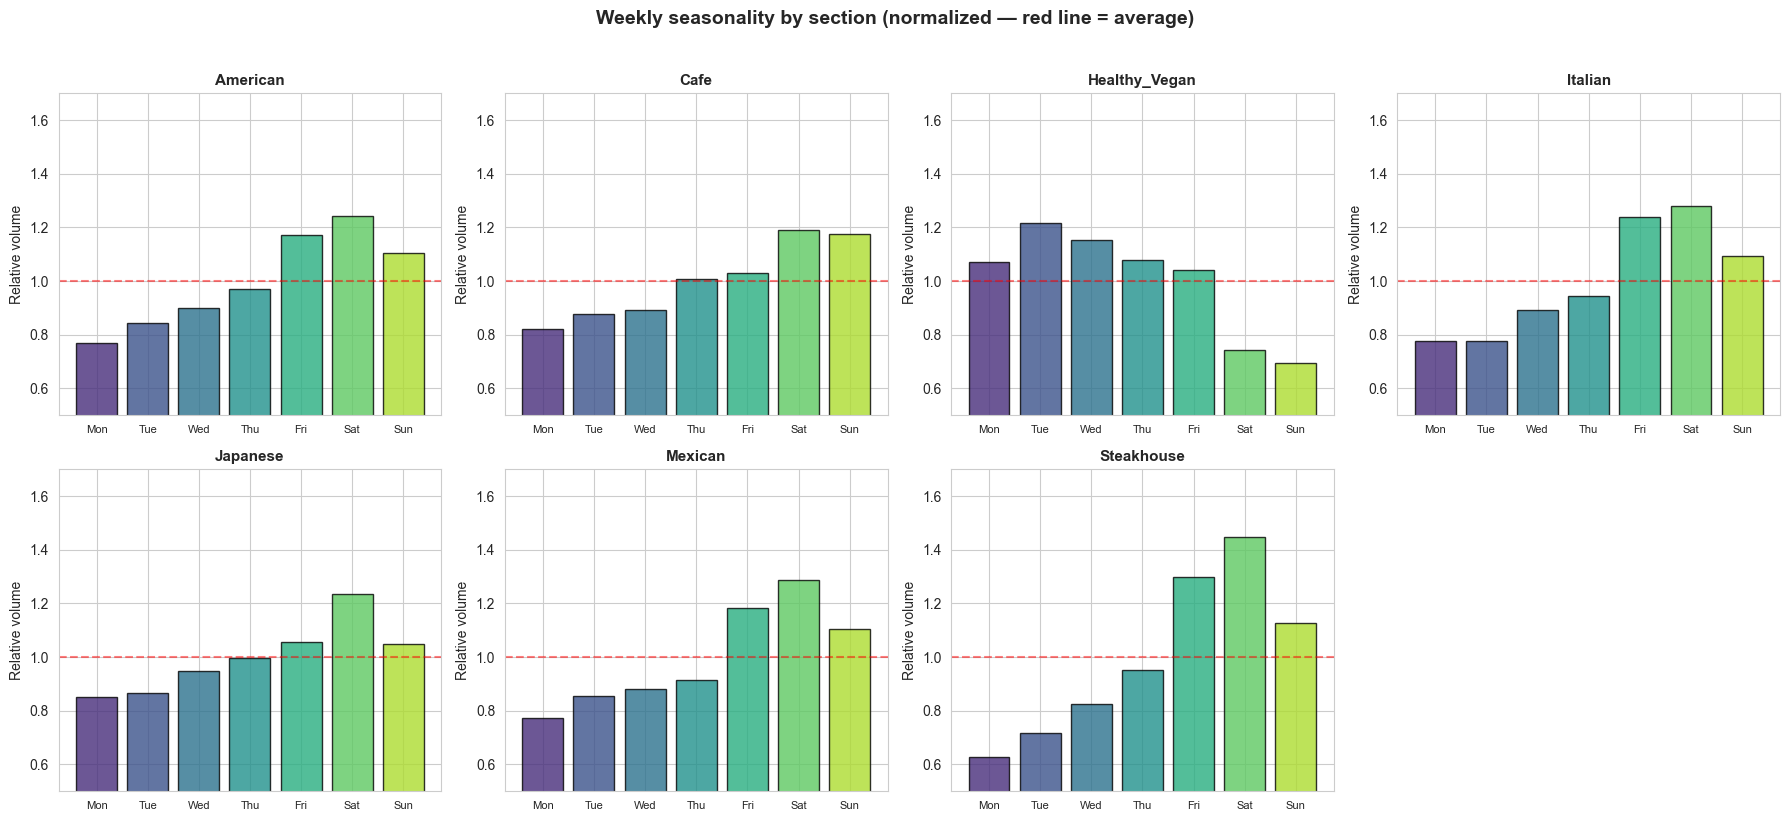

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
sections = sorted(demand['section'].unique())
wd_names_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for i, section in enumerate(sections):
    sub = demand[demand['section'] == section]
    wd_sect = sub.groupby(['order_date', 'weekday'])['quantity'].sum().reset_index()
    wd_sect_avg = wd_sect.groupby('weekday')['quantity'].mean()
    
    # Normalize to show shape
    normalized = wd_sect_avg / wd_sect_avg.mean()
    
    axes[i].bar(range(7), normalized.values, color=sns.color_palette('viridis', 7),
                edgecolor='black', alpha=0.8)
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(wd_names_short, fontsize=8)
    axes[i].set_title(section, fontsize=11, fontweight='bold')
    axes[i].axhline(1.0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_ylim(0.5, 1.7)
    axes[i].set_ylabel('Relative volume')

axes[-1].axis('off')
plt.suptitle('Weekly seasonality by section (normalized — red line = average)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Monthly seasonality

Are there months that are consistently busier? Summer vs winter effects?

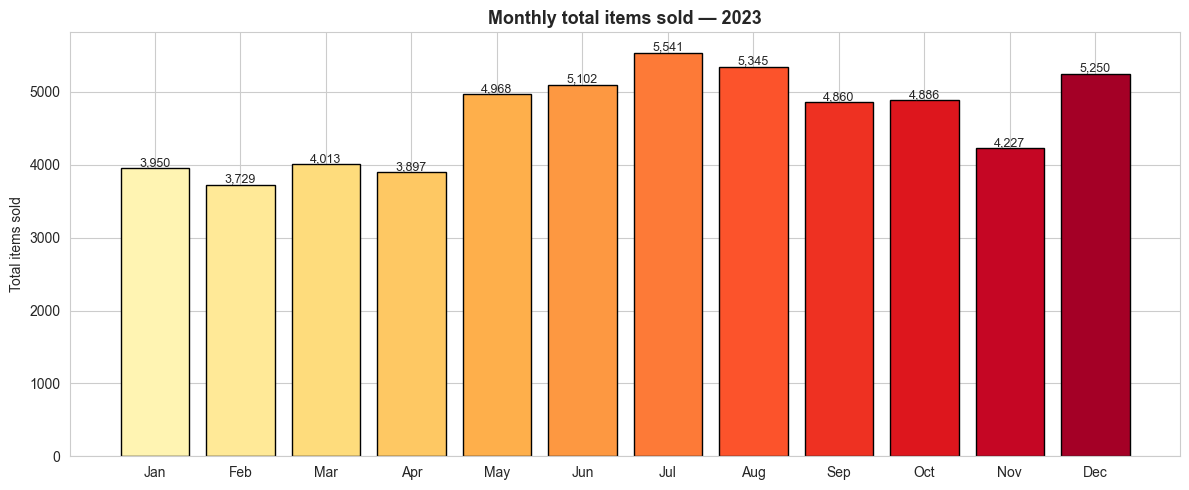

Peak month: Jul (5,541 items)
Trough month: Feb (3,729 items)
Peak-to-trough swing: 49%


In [6]:
# Monthly totals for full year 2023
monthly = demand[demand['year'] == 2023].groupby('month')['quantity'].sum()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('YlOrRd', 12)
bars = ax.bar(month_labels, monthly.values, color=colors, edgecolor='black')
ax.set_title('Monthly total items sold — 2023')
ax.set_ylabel('Total items sold')
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

peak = monthly.idxmax()
trough = monthly.idxmin()
swing = (monthly.max() / monthly.min() - 1) * 100
print(f"Peak month: {month_labels[peak-1]} ({monthly.max():,} items)")
print(f"Trough month: {month_labels[trough-1]} ({monthly.min():,} items)")
print(f"Peak-to-trough swing: {swing:.0f}%")

## 5. Holiday and Ramadan effects on item demand

### 5.1 Ramadan impact per section

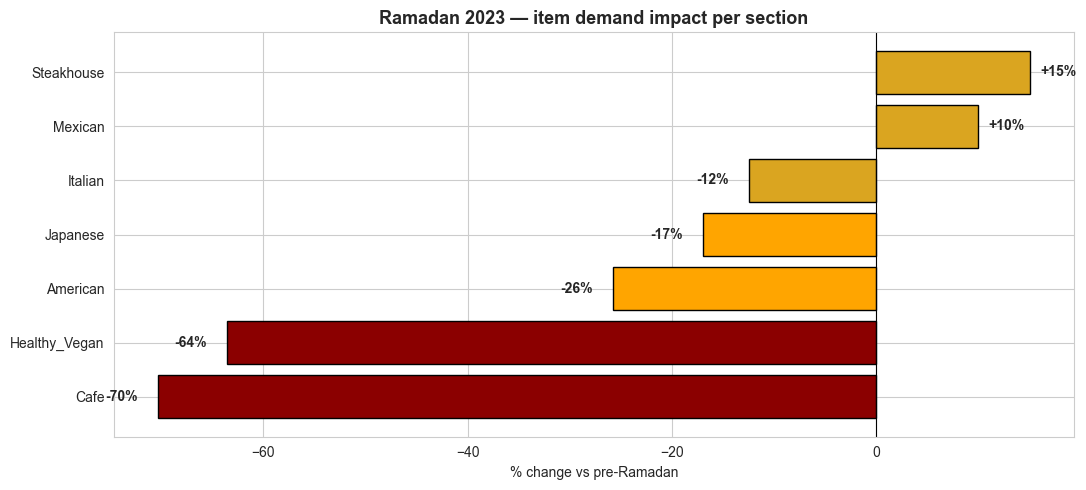

In [7]:
# Ramadan 2023: Mar 22 - Apr 20
ram_start = pd.Timestamp('2023-03-22')
ram_end = pd.Timestamp('2023-04-20')
pre_start = pd.Timestamp('2023-02-20')
pre_end = pd.Timestamp('2023-03-21')

ramadan_impact = []
for section in sections:
    sub = demand[demand['section'] == section]
    daily_sect = sub.groupby('order_date')['quantity'].sum()
    
    pre = daily_sect[(daily_sect.index >= pre_start) & (daily_sect.index <= pre_end)].mean()
    during = daily_sect[(daily_sect.index >= ram_start) & (daily_sect.index <= ram_end)].mean()
    change = (during / pre - 1) * 100 if pre > 0 else 0
    ramadan_impact.append({'section': section, 'pre_ramadan': pre, 'during_ramadan': during, 'change_pct': change})

ri = pd.DataFrame(ramadan_impact).sort_values('change_pct')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['darkred' if v < -30 else 'orange' if v < -15 else 'goldenrod'
          for v in ri['change_pct']]
bars = ax.barh(ri['section'], ri['change_pct'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ramadan 2023 — item demand impact per section')
ax.set_xlabel('% change vs pre-Ramadan')
for bar, val in zip(bars, ri['change_pct']):
    ax.text(val - 2 if val < 0 else val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha='right' if val < 0 else 'left',
            fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

### 5.2 Holiday spikes — item-level impact

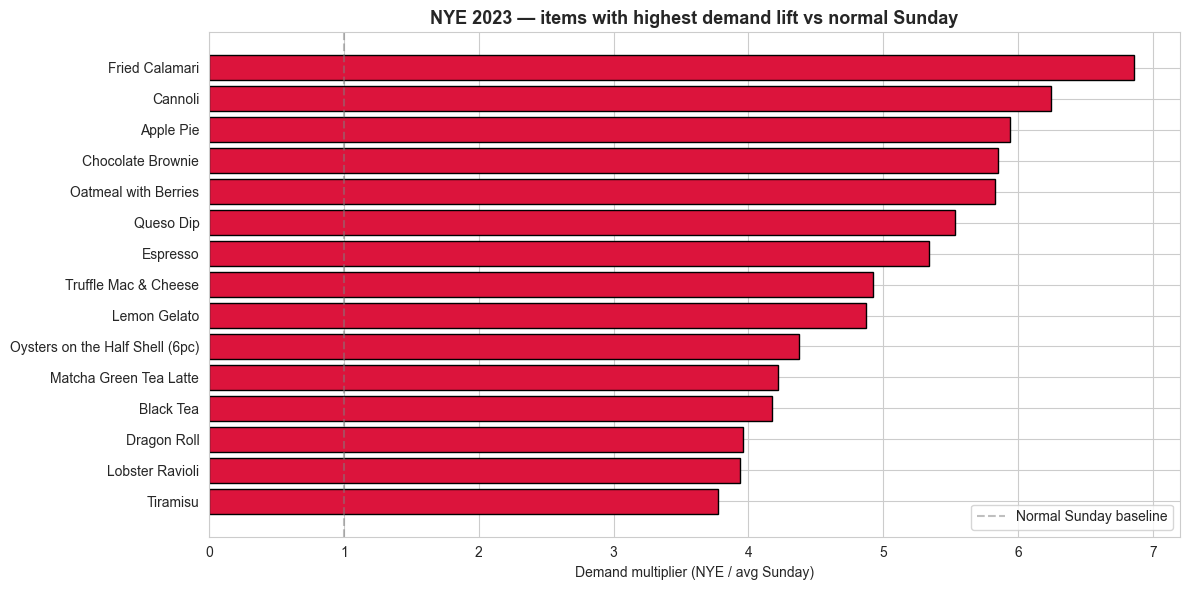

In [8]:
# Compare top 5 items on NYE vs normal days
nye_2023 = pd.Timestamp('2023-12-31')
normal_days = demand[(demand['order_date'].dt.weekday == 6) &  # Sundays
                     (~demand['order_date'].isin([nye_2023]))]['order_date'].unique()

# Average Sunday demand per item
sunday_avg = demand[demand['order_date'].isin(normal_days)].groupby('item_name')['quantity'].mean()

# NYE demand per item
nye_demand = demand[demand['order_date'] == nye_2023].set_index('item_name')['quantity']

# Compute lift
holiday_lift = (nye_demand / sunday_avg).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_items = holiday_lift.head(15)
colors = ['crimson' if v > 3 else 'coral' if v > 2 else 'salmon' for v in top_items.values]
ax.barh(top_items.index[::-1], top_items.values[::-1], color=colors[::-1], edgecolor='black')
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Normal Sunday baseline')
ax.set_title('NYE 2023 — items with highest demand lift vs normal Sunday')
ax.set_xlabel('Demand multiplier (NYE / avg Sunday)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Item-level seasonality — summer vs winter items

Do specific items have seasonal demand patterns? This is critical for
per-item forecasting — the model needs to learn that Iced Latte peaks in
summer while Cappuccino peaks in winter.

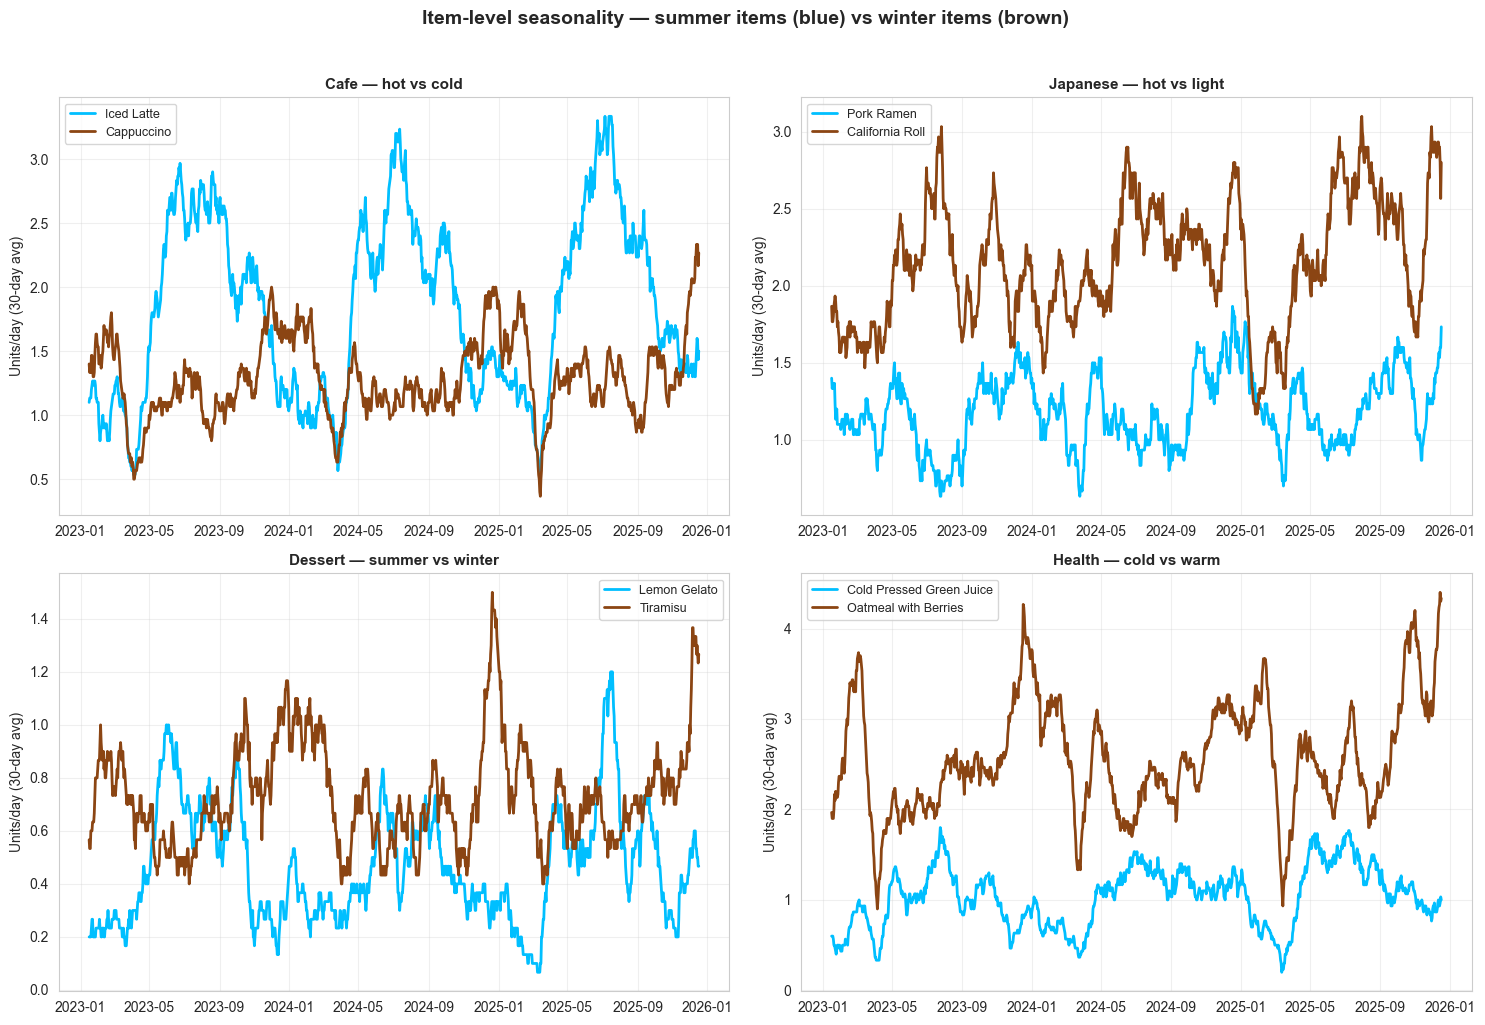

In [9]:
# Pick contrasting item pairs to visualize
seasonal_pairs = [
    ('Iced Latte', 'Cappuccino', 'Cafe — hot vs cold'),
    ('Pork Ramen', 'California Roll', 'Japanese — hot vs light'),
    ('Lemon Gelato', 'Tiramisu', 'Dessert — summer vs winter'),
    ('Cold Pressed Green Juice', 'Oatmeal with Berries', 'Health — cold vs warm'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (item_a, item_b, title) in enumerate(seasonal_pairs):
    ax = axes[idx]
    for item, color, style in [(item_a, 'deepskyblue', '-'), (item_b, 'saddlebrown', '-')]:
        item_daily = demand[demand['item_name'] == item].groupby('order_date')['quantity'].sum()
        # 30-day rolling to show seasonal shape
        rolling = item_daily.rolling(30, center=True).mean()
        ax.plot(rolling.index, rolling.values, style, color=color, linewidth=2, label=item)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Units/day (30-day avg)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Item-level seasonality — summer items (blue) vs winter items (brown)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What to look for:** if the blue and brown lines move in opposite
directions across the year, that's seasonal demand — the model needs month
or season features to capture it. If they move together, the seasonality is
at the aggregate level (total restaurant demand) not item-specific.

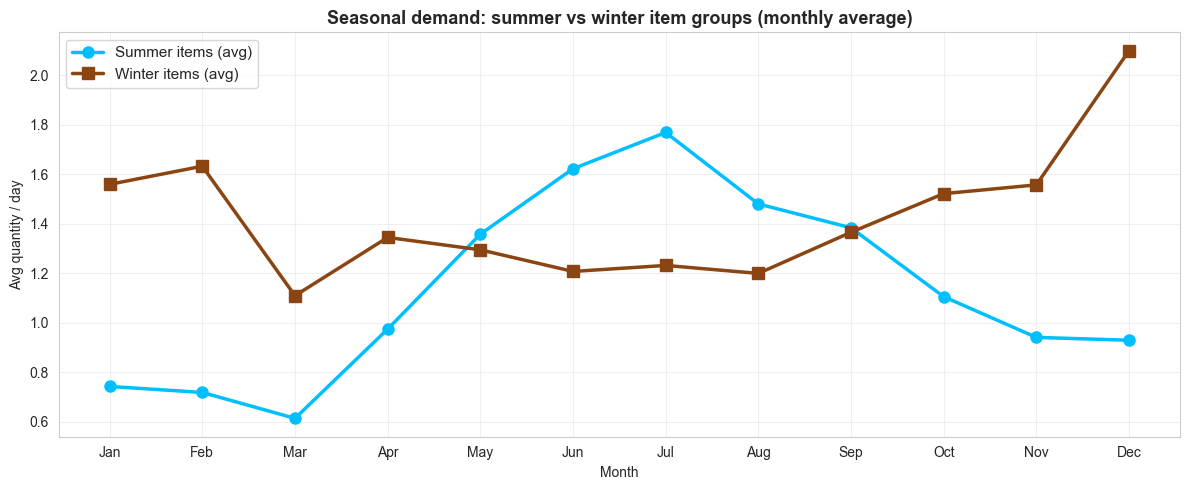

Summer items: peak/trough ratio = 2.89x
Winter items: peak/trough ratio = 1.89x


In [10]:
# Quantify: monthly demand ratio for summer vs winter items
summer_items = ['Iced Latte', 'Cold Brew Coffee', 'Fruit Smoothie', 'Cold Pressed Green Juice',
                'Coconut Water', 'Lemon Gelato', 'Classic Margarita', 'Corona Extra']
winter_items = ['Cappuccino', 'Espresso', 'Pork Ramen', 'Beef Lasagna',
                'Hot Sake (Small)', 'Oatmeal with Berries', 'Red Wine (Chianti)', 'Tiramisu']

summer_monthly = demand[demand['item_name'].isin(summer_items)].groupby('month')['quantity'].mean()
winter_monthly = demand[demand['item_name'].isin(winter_items)].groupby('month')['quantity'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = range(1, 13)
ax.plot(x, summer_monthly.reindex(x).values, 'o-', color='deepskyblue',
        linewidth=2.5, markersize=8, label='Summer items (avg)')
ax.plot(x, winter_monthly.reindex(x).values, 's-', color='saddlebrown',
        linewidth=2.5, markersize=8, label='Winter items (avg)')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_title('Seasonal demand: summer vs winter item groups (monthly average)')
ax.set_ylabel('Avg quantity / day')
ax.set_xlabel('Month')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compute seasonal amplitude
summer_peak = summer_monthly.max()
summer_trough = summer_monthly.min()
winter_peak = winter_monthly.max()
winter_trough = winter_monthly.min()
print(f"Summer items: peak/trough ratio = {summer_peak/summer_trough:.2f}x")
print(f"Winter items: peak/trough ratio = {winter_peak/winter_trough:.2f}x")

## 7. Autocorrelation analysis

How far back does past demand predict future demand? This determines which
**lag features** we build in the feature engineering notebook. If lag-7 has
high autocorrelation, it means "same day last week" is a strong predictor.

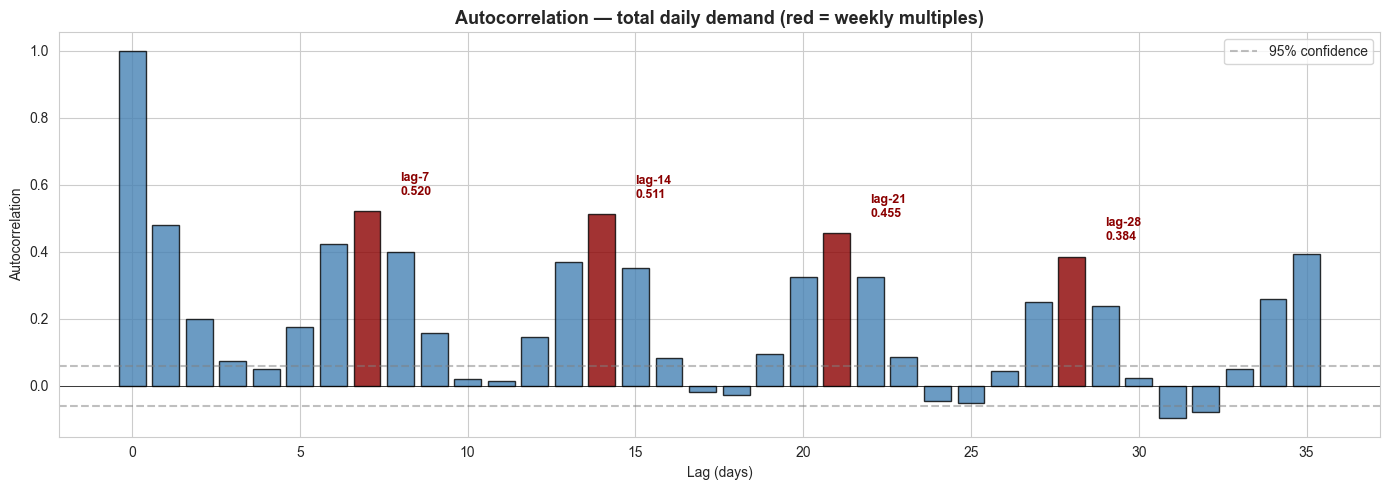

Key autocorrelation values:
  Lag- 1: 0.4809
  Lag- 2: 0.1989
  Lag- 3: 0.0732
  Lag- 7: 0.5204
  Lag-14: 0.5115
  Lag-21: 0.4547
  Lag-28: 0.3843


In [11]:
from statsmodels.tsa.stattools import acf

# Compute autocorrelation on total daily demand
acf_values = acf(daily_total, nlags=35, fft=True)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['darkred' if i in [7, 14, 21, 28] else 'steelblue' for i in range(len(acf_values))]
ax.bar(range(len(acf_values)), acf_values, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Autocorrelation — total daily demand (red = weekly multiples)')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(1.96/np.sqrt(len(daily_total)), linestyle='--', color='gray', alpha=0.5, label='95% confidence')
ax.axhline(-1.96/np.sqrt(len(daily_total)), linestyle='--', color='gray', alpha=0.5)

# Annotate weekly peaks
for lag in [7, 14, 21, 28]:
    ax.annotate(f'lag-{lag}\n{acf_values[lag]:.3f}',
                xy=(lag, acf_values[lag]),
                xytext=(lag + 1, acf_values[lag] + 0.05),
                fontsize=9, fontweight='bold', color='darkred')
ax.legend()
plt.tight_layout()
plt.show()

print("Key autocorrelation values:")
for lag in [1, 2, 3, 7, 14, 21, 28]:
    print(f"  Lag-{lag:>2}: {acf_values[lag]:.4f}")

**Reading the autocorrelation plot.** The red bars at lags 7, 14, 21, 28
are the **weekly multiples** — if they spike above the blue bars, the weekly
cycle is the dominant pattern. This tells us:
- **lag-7 (same day last week) should be our strongest feature**
- **lag-14 and lag-21 add diminishing value**
- **lag-1 (yesterday) may have moderate correlation** but includes the within-week
  pattern rather than being truly predictive

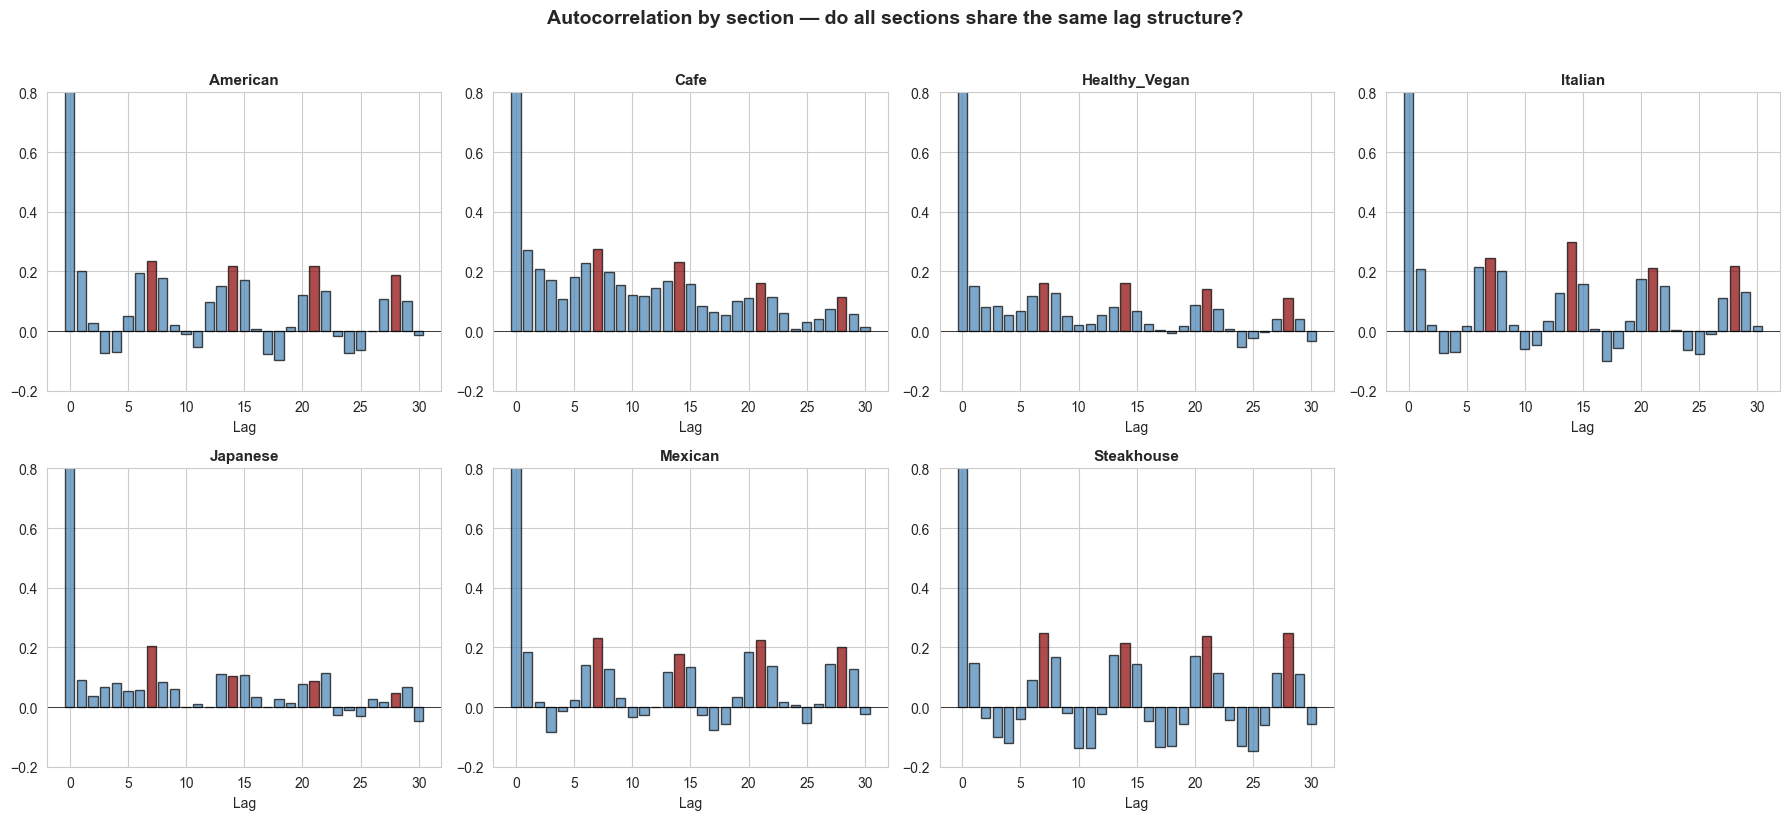

In [12]:
# Autocorrelation per section
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, section in enumerate(sections):
    sub = demand[demand['section'] == section].groupby('order_date')['quantity'].sum()
    acf_sect = acf(sub, nlags=30, fft=True)
    
    colors = ['darkred' if j in [7, 14, 21, 28] else 'steelblue' for j in range(len(acf_sect))]
    axes[i].bar(range(len(acf_sect)), acf_sect, color=colors, edgecolor='black', alpha=0.7)
    axes[i].set_title(section, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylim(-0.2, 0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)

axes[-1].axis('off')
plt.suptitle('Autocorrelation by section — do all sections share the same lag structure?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Time series decomposition

Decompose the aggregate demand into trend, seasonal, and residual components
using the classical additive model. This gives a visual confirmation of what
the forecasting model needs to learn.

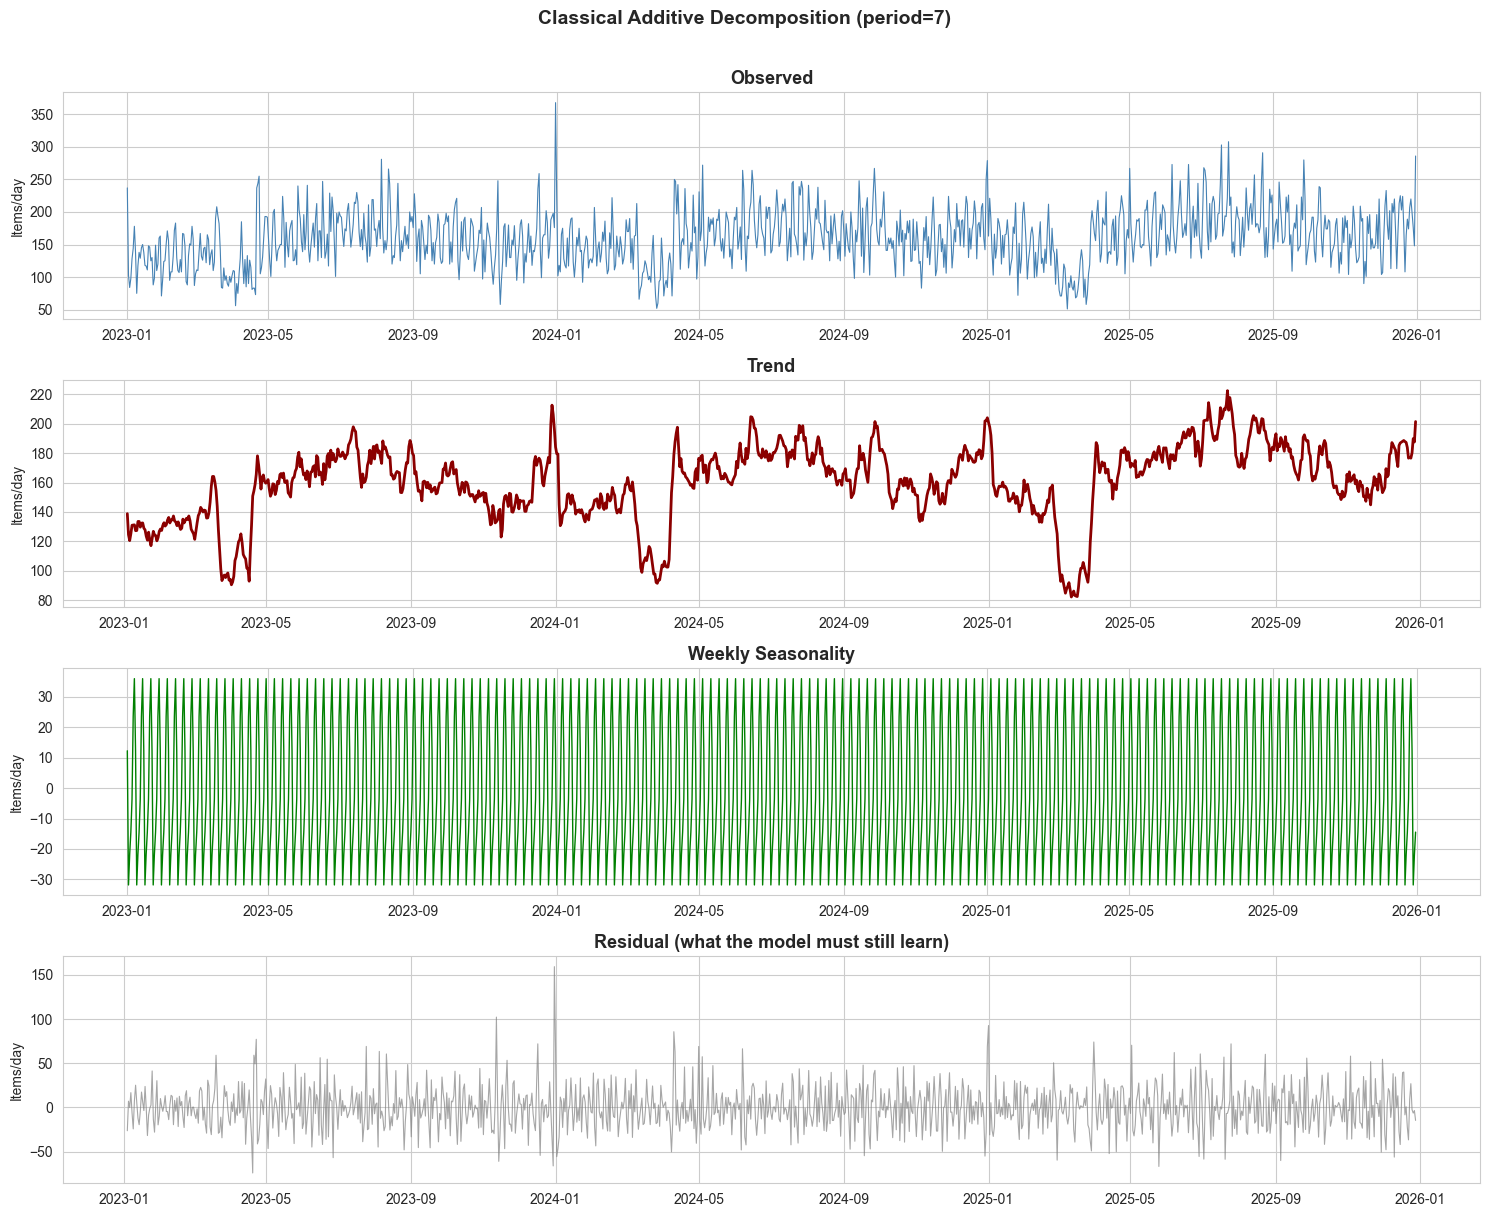

Variance explained by trend + weekly seasonality: 66.5%
Remaining (residual): 33.5%

The residual includes: holiday effects, Ramadan, item-level seasonality,
random noise. Our ML models need to capture as much of this as possible.


In [13]:
# Decompose aggregate daily total (period=7 for weekly seasonality)
decomposition = seasonal_decompose(daily_total, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

axes[0].plot(daily_total.index, daily_total.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('Items/day')

axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='darkred', linewidth=2)
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Items/day')

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='green', linewidth=1)
axes[2].set_title('Weekly Seasonality', fontweight='bold')
axes[2].set_ylabel('Items/day')

axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='gray', linewidth=0.8, alpha=0.7)
axes[3].set_title('Residual (what the model must still learn)', fontweight='bold')
axes[3].set_ylabel('Items/day')

plt.suptitle('Classical Additive Decomposition (period=7)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Compute variance explained
total_var = daily_total.var()
resid_var = decomposition.resid.dropna().var()
explained = (1 - resid_var / total_var) * 100
print(f"Variance explained by trend + weekly seasonality: {explained:.1f}%")
print(f"Remaining (residual): {100 - explained:.1f}%")
print(f"\nThe residual includes: holiday effects, Ramadan, item-level seasonality,")
print(f"random noise. Our ML models need to capture as much of this as possible.")

## 9. EDA findings — transfer to forecasting tracks

This EDA was conducted at daily granularity to fully characterize the data.
The patterns found inform two parallel modeling tracks at different time
resolutions:

| Pattern found (daily EDA) | Daily anomaly detection (Module 4) | Weekly forecasting (Module 2) |
|---|---|---|
| Weekly seasonality (Sat/Mon 1.5×) | ✓ Used | ✗ Aggregated away |
| Day-of-week × section interaction | ✓ Used | ✗ Aggregated away |
| Hourly transaction patterns | ✓ Used | ✗ Aggregated away |
| Monthly seasonality (~30% swing) | — | ✓ `month_sin`/`month_cos` features |
| Long-term growth (+15% / 18mo) | — | ✓ `weeks_since_start` feature |
| Ramadan suppression (-66% Cafe) | ✓ Used | ✓ `is_ramadan_week` + interactions |
| Holiday spikes (NYE 6× desserts) | ✓ Used | ✓ `n_holidays_in_week` + interactions |
| Item seasonality (summer/winter) | — | ✓ `month × section` interaction |
| Lag-7 daily autocorrelation (0.49) | ✓ Anomaly threshold tuning | ✓ Becomes lag-1 week |
| Cross-item demand correlation | — | ✓ `total_lag_1`, `section_lag_1` (hierarchical features) |

**Why daily EDA still matters for weekly forecasting:**

- **Sub-weekly patterns (weekday effects, hourly distributions) inform Module 4.**
  Anomaly detection needs daily granularity to catch one-off events like a
  suspicious Tuesday or a register cash mismatch on a specific shift.

- **Patterns at weekly+ resolution (seasonality, holidays, trend) inform Module 2.**
  These translate naturally to weekly features without information loss.

- **Cross-resolution insights:** daily ACF showed lag-7 = 0.49 (the strongest
  single signal). At weekly granularity, this becomes lag-1 week — same
  predictive power, different time scale.

This separation produces two specialized models that each match their
operational context, rather than one compromise model that handles neither
well.

## Summary

The EDA confirmed several findings critical for downstream modeling:

- **Demand has clear monthly and weekly seasonality** (weekly aggregated away
  for forecasting; preserved for anomaly detection)
- **Ramadan and holidays produce large, uneven impacts** that vary by section
  (Cafe / Healthy_Vegan most affected; American least affected) — must be
  modeled explicitly
- **Item-level seasonality is heterogeneous** — summer/winter items invert
  (Iced Latte ↔ Cappuccino), motivating the `month × section` interaction
- **Per-item daily series are noisy** (CV 0.6-1.5, 64% values are 0 or 1) —
  motivating the shift to weekly granularity for forecasting
- **Lag-7 autocorrelation (0.49) is the dominant single signal** — informs
  feature engineering at both granularities

**Next:**
- `03_feature_engineering_weekly.ipynb` — build the weekly feature matrix
- `04a_prophet_weekly.ipynb` → `04b_sarima_weekly.ipynb` → `04c_statistical_comparison_weekly.ipynb`
- `05a_xgboost_global_weekly.ipynb` → `05b_lightgbm_global_weekly.ipynb` → `05c_ml_comparison_weekly.ipynb`
- `06a_lstm_global_weekly.ipynb` → `06b_tft_global_weekly.ipynb` → `06c_dl_comparison_weekly.ipynb`
- `07_final_comparison_weekly.ipynb`
- `08_stock_alerts.ipynb`